# 006 — SME hyperbolicity: structure, regularizations, and what route B reveals

**Question.** SME L≥1 loses hyperbolicity at finite states; the standard
Koellermeier–Torrilhon (K&T) regularisation makes it hyperbolic at the price
of a sizeable perturbation to the flux Jacobian. **Can we do less?**

This notebook works through four findings developed in `tutorials/sme/`:
1. Two equivalent constructions of SME L=2 — *route A* (close `w` via
   depth-integrated continuity) and *route B* (keep `w` explicit, with
   algebraic constraints). They give identical eigenvalues but route B
   exposes structure that route A hides.
2. The destabilising piece of the flux Jacobian is exactly the Schur
   complement of route B's algebraic w-block — a delicate near-cancellation.
3. The loss of hyperbolicity lives in a 2-D subspace spanned by the top
   two moments. The shallow-water modes `(h, u_0)` are spectators.
4. One single entry of the principal-symbol matrix needs to be zeroed for
   full hyperbolicity. The Frobenius norm of this perturbation is ~5×
   smaller than K&T's drop-feedback.

At the end we discuss whether these results scale to higher L and whether
eigenvalue computation alone constitutes a proof.

## Setup

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, "../tutorials/sme")
from sme_l2_hyperbolicity_compare import (
    build_route_a, build_route_b, _flat_bottom,
    h, u_0, u_1, u_2, g,
)
from zoomy_core.analysis import linearise, extract_quasilinear_pencil
from zoomy_core.symbolic import polynomial_integrate as poly_int

## 1. Route A vs route B

**Route A** closes `w` via the depth-integrated continuity equation
(`w(z) = u(b)·∂_x b − ∫_b^z ∂_x u dz'`), substitutes back into x-momentum,
and projects against `φ_0..φ_M`. State: `(h, u_0, u_1, u_2)` — 4 evolution
equations.

**Route B** keeps `w(t,x,z) = Σ w_i(t,x) φ_i((z−b)/h)` explicit with
`N_w = M+1 = 3` (4 modes), giving 8 unknowns. The four cont projections
and KBC_bot supply 4 algebraic constraints. KBC_top + the 3 x-mom
projections supply 4 evolution-like equations.

Both should produce *identical* eigenvalues in the principal-symbol limit.

In [2]:
sa = _flat_bottom(build_route_a())
sb = _flat_bottom(build_route_b())
print(f"Route A: {len(sa.equations)} equations × {len(sa.fields)} fields")
print(f"Route B: {len(sb.equations)} equations × {len(sb.fields)} fields")

Route A: 4 equations × 4 fields
Route B: 8 equations × 8 fields


### Linearise both around a homogeneous base, extract pencils

In [3]:
base_a = {f: sp.Symbol(f.func.__name__ + "_bar", real=True) for f in sa.fields}
base_b = {f: sp.Symbol(f.func.__name__ + "_bar", real=True) for f in sb.fields}
M_t_a, [M_x_a], _ = extract_quasilinear_pencil(linearise(sa, base_a))
M_t_b, [M_x_b], M_0_b = extract_quasilinear_pencil(linearise(sb, base_b))
print(f"Route A pencil: M_x = {M_x_a.shape}, M_t rank {M_t_a.rank()}")
print(f"Route B pencil: M_x = {M_x_b.shape}, M_t rank {M_t_b.rank()}  "
      f"(rank-deficiency = #algebraic constraints = "
      f"{M_t_b.rows - M_t_b.rank()})")

Route A pencil: M_x = (4, 4), M_t rank 4
Route B pencil: M_x = (8, 8), M_t rank 4  (rank-deficiency = #algebraic constraints = 4)


## 2. Block structure of route B

Order route B's fields as `(evol = h, u_0, u_1, u_2)` then `(w = w_0..w_3)`.
The 8×8 pencil splits cleanly:

In [4]:
M_t_uu = M_t_b[:4, :4]
M_x_uu = M_x_b[:4, :4]
M_x_au = M_x_b[4:, :4]
M_0_uw = M_0_b[:4, 4:]
M_0_aw = M_0_b[4:, 4:]
print("M_x_uw (evolution rows × w columns of M_x):")
sp.pprint(sp.simplify(M_x_b[:4, 4:]))
print("M_x_aw (algebraic rows × w columns of M_x):")
sp.pprint(sp.simplify(M_x_b[4:, 4:]))
print("\nM_0_aw (algebraic rows × w columns of M_0)  ← *constant* matrix:")
sp.pprint(sp.simplify(M_0_aw))
print(f"det(M_0_aw) = {sp.simplify(M_0_aw.det())}  (independent of base state)")

M_x_uw (evolution rows × w columns of M_x):
⎡0  0  0  0⎤
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎣0  0  0  0⎦
M_x_aw (algebraic rows × w columns of M_x):
⎡0  0  0  0⎤
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎣0  0  0  0⎦

M_0_aw (algebraic rows × w columns of M_0)  ← *constant* matrix:
⎡0  -2  0   -2⎤
⎢             ⎥
⎢0  0   -2  0 ⎥
⎢             ⎥
⎢0  0   0   -2⎥
⎢             ⎥
⎣1  1   1   1 ⎦
det(M_0_aw) = 8  (independent of base state)


Three key sparsity facts:
* `M_x_uw = 0` — `w` never appears with `∂_x` in evolution rows.
* `M_x_aw = 0` — same for algebraic rows.
* `M_0_aw` is the constant matrix `[[0,−2,0,−2], [0,0,−2,0], [0,0,0,−2], [1,1,1,1]]`,
  determinant 8, independent of `(h̄, ū_i)`.

Therefore the Schur complement that returns route A is a closed-form expression:

$$
M_x^{\text{eff}} \;=\; M_x^{(\text{evol},\text{evol})} \;-\; M_0^{(\text{evol},w)}\,(M_0^{(\text{alg},w)})^{-1}\,M_x^{(\text{alg},\text{evol})}
$$

Inspecting the `(xmom_j0, h-col)` entry, the `u_1²` and `u_2²` coefficients split as:

|              | `u_1²/3` | `u_2²/5` |
|--------------|----------|----------|
| `M_x_uu` direct  | **−1/3** (stabilising) | **−2/5** (stabilising) |
| feedback (Schur) | **+2/3** (destabilising) | **+3/5** (destabilising) |
| total (route A)  | +1/3 | +1/5 |

**The K&T-style destabiliser lives entirely in the Schur-complement feedback.**

## 3. Loss-of-hyperbolicity is a (u_1, u_2) phenomenon

Sample `A := M_t_uu^{−1}·M_x_eff` over a `(ū_1, ū_2)` grid; find the
unstable eigenvector at a corner spur and decompose it.

In [5]:
M_x_eff = M_x_uu - M_0_uw * M_0_aw.inv() * M_x_au
syms_b = [g, base_b[h], base_b[u_0], base_b[u_1], base_b[u_2]]
f_M_t = sp.lambdify(syms_b, M_t_uu, "numpy")
f_M_x = sp.lambdify(syms_b, M_x_eff, "numpy")

# Pick a corner spur:
params = (1.0, 1.0, 0.0, 1.5, 1.8)   # (g, H, U_0, U_1, U_2)
Mt_n = np.asarray(f_M_t(*params), float)
Mx_n = np.asarray(f_M_x(*params), float)
A = np.linalg.solve(Mt_n, Mx_n)
eigs, vecs = np.linalg.eig(A)
bad = np.argmax(np.abs(eigs.imag))
v = vecs[:, bad] / np.max(np.abs(vecs[:, bad]))
amp_sq = np.abs(v)**2
labels = ["h", "u_0", "u_1", "u_2"]
print(f"At (ū_1, ū_2) = (1.5, 1.8):  λ = {eigs[bad]:.4f}")
print("|amplitude|² fraction of the unstable mode:")
for label, val in zip(labels, amp_sq):
    bar = "█" * int(val * 50)
    print(f"  {label}:  {val:5.1%}  {bar}")

At (ū_1, ū_2) = (1.5, 1.8):  λ = 0.4895+0.0631j
|amplitude|² fraction of the unstable mode:
  h:   3.9%  █
  u_0:   1.0%  
  u_1:  33.8%  ████████████████
  u_2:  100.0%  ██████████████████████████████████████████████████


The unstable mode is essentially a `(u_1, u_2)` oscillation — `(h, u_0)`
barely participate. **The same pattern holds at L=3:** of 44 unstable
samples in a `(ū_2, ū_3)` scan, the top-2 modes carry 92% of the
eigenvector energy on average; `(u_2, u_3)` is the dominant pair in
90.9% of unstable samples. So at level L the destabiliser is a
`(u_{L−1}, u_L)` interaction.

## 4. The single-entry minimum-perturbation regularisation

Sweep all single-entry zeroings of `A`. Track non-hyperbolic % over the
`(ū_1, ū_2)` grid and the Frobenius-norm distance from the original.

In [6]:
H, U0, gv = 1.0, 0.0, 1.0
n_pts = 41
u1g = np.linspace(-3.0, 3.0, n_pts)
u2g = np.linspace(-2.0, 2.0, n_pts)

def _eval(U1, U2):
    Mt = np.asarray(f_M_t(gv, H, U0, float(U1), float(U2)), float)
    Mx = np.asarray(f_M_x(gv, H, U0, float(U1), float(U2)), float)
    return np.linalg.solve(Mt, Mx)

# Grid of full A's
A_grid = np.array([[_eval(U1, U2) for U2 in u2g] for U1 in u1g])
# Original (full SME L=2):
nh_orig = float(np.mean([
    np.max(np.abs(np.imag(np.linalg.eigvals(A))) ) > 1e-6
    for A in A_grid.reshape(-1, 4, 4)
]))
print(f"Full SME L=2:  {nh_orig:.2%} non-hyperbolic")

# Try every single (r, c) zeroing.
# **Exclude the shallow-water block A[0:2, 0:2]** — entries there
# (e.g., A[0,1] = h̄, A[1,0] = g·h̄ + ...) generate the gravity wave;
# zeroing them gives "real eigenvalues" by trivially decoupling
# (h, u_0), which is not a meaningful regularisation.
best = None
all_results = []
for r in range(4):
    for c in range(4):
        if r == c:
            continue
        if r < 2 and c < 2:
            continue   # skip shallow-water block
        nh = 0
        fro = 0.0
        for A in A_grid.reshape(-1, 4, 4):
            A_mod = A.copy(); A_mod[r, c] = 0
            nh += int(np.max(np.abs(np.imag(np.linalg.eigvals(A_mod)))) > 1e-6)
            fro += np.linalg.norm(A_mod - A, "fro")
        nh /= n_pts**2
        fro /= n_pts**2
        all_results.append(((r, c), nh, fro))
        if nh < 1e-9 and (best is None or fro < best[2]):
            best = ((r, c), nh, fro)

print(f"\nMinimum-norm single-entry fix (excluding shallow-water block):")
print(f"  A[{best[0][0]}, {best[0][1]}] = 0")
print(f"  non-hyperbolic %: {best[1]:.2%}")
print(f"  ⟨‖·‖_F⟩:          {best[2]:.3f}")
print()
print("Top single-entry candidates (sorted by Frobenius distance):")
all_results.sort(key=lambda x: (x[1], x[2]))
for (r, c), nh, fro in all_results[:8]:
    flag = "✓" if nh < 1e-9 else "✗"
    print(f"  {flag}  A[{r}, {c}]=0   non-hyp {nh:.2%}   ⟨‖·‖_F⟩ {fro:.3f}")

Full SME L=2:  1.67% non-hyperbolic

Minimum-norm single-entry fix (excluding shallow-water block):
  A[1, 2] = 0
  non-hyperbolic %: 0.00%
  ⟨‖·‖_F⟩:          1.024

Top single-entry candidates (sorted by Frobenius distance):
  ✓  A[1, 2]=0   non-hyp 0.00%   ⟨‖·‖_F⟩ 1.024
  ✓  A[2, 0]=0   non-hyp 0.00%   ⟨‖·‖_F⟩ 1.259
  ✗  A[3, 0]=0   non-hyp 1.43%   ⟨‖·‖_F⟩ 0.937
  ✗  A[0, 3]=0   non-hyp 1.67%   ⟨‖·‖_F⟩ 0.000
  ✗  A[0, 2]=0   non-hyp 1.67%   ⟨‖·‖_F⟩ 0.000
  ✗  A[3, 2]=0   non-hyp 5.47%   ⟨‖·‖_F⟩ 0.512
  ✗  A[3, 1]=0   non-hyp 8.33%   ⟨‖·‖_F⟩ 1.024
  ✗  A[1, 3]=0   non-hyp 20.23%   ⟨‖·‖_F⟩ 0.410


### What's that entry, in PDE terms?

In [7]:
# Compute symbolic A[1,2] from route A directly (cleaner labelling).
# Route A row 1 = xmom_j0 (mean-flow x-momentum).  M_t_a is diagonal
# with entries (1, h, h/3, h/5).
M_t_a_inv = M_t_a.inv()
A_sym_route_a = M_t_a_inv * M_x_a
print("Symbolic A[1, 2] (route A) =", sp.simplify(A_sym_route_a[1, 2]))
print("Symbolic M_x[1, 2] (xmom_j0 row, u_1 col) =",
      sp.simplify(M_x_a[1, 2]))
print()
print("This is the (2/3)·h̄·ū_1 coefficient of ∂_x δu_1 in the linearised")
print("xmom_j0 (mean-flow x-momentum) equation.  It is the linearisation of")
print("the term  ∂_x(h u_1²/3)  in the conservative SME flux:")
print()
print("  ∂_x(h u_1²/3) = (2/3) h u_1 ∂_x u_1 + (1/3) u_1² ∂_x h")
print()
print("Zeroing A[1,2] removes the **first** term — the convective transport of")
print("the u_1-variance by the local u_1 — but keeps the second (geometric)")
print("forcing (1/3) u_1²·∂_x h.")

Symbolic A[1, 2] (route A) = 2*u_1_bar/3
Symbolic M_x[1, 2] (xmom_j0 row, u_1 col) = 2*h_bar*u_1_bar/3

This is the (2/3)·h̄·ū_1 coefficient of ∂_x δu_1 in the linearised
xmom_j0 (mean-flow x-momentum) equation.  It is the linearisation of
the term  ∂_x(h u_1²/3)  in the conservative SME flux:

  ∂_x(h u_1²/3) = (2/3) h u_1 ∂_x u_1 + (1/3) u_1² ∂_x h

Zeroing A[1,2] removes the **first** term — the convective transport of
the u_1-variance by the local u_1 — but keeps the second (geometric)
forcing (1/3) u_1²·∂_x h.


**PDE-level interpretation.** The minimum-norm regularisation replaces

$$
\partial_x\!\left(\tfrac{h\, u_1^2}{3}\right)
\quad\longrightarrow\quad
\tfrac{u_1^2}{3}\,\partial_x h
$$

in the mean-flow x-momentum equation. The convective transport is
removed; the depth-gradient forcing is kept. **Crucially the modification
is to a single flux entry — not a global re-shaping of the Jacobian.**

Compare with K&T's drop-feedback (Frobenius distance ~4.85) and our
cross-coupling-zero (off-diagonal block, ~2.88). The single-entry fix is
**~5× smaller than K&T**.

## 5. Visualisation

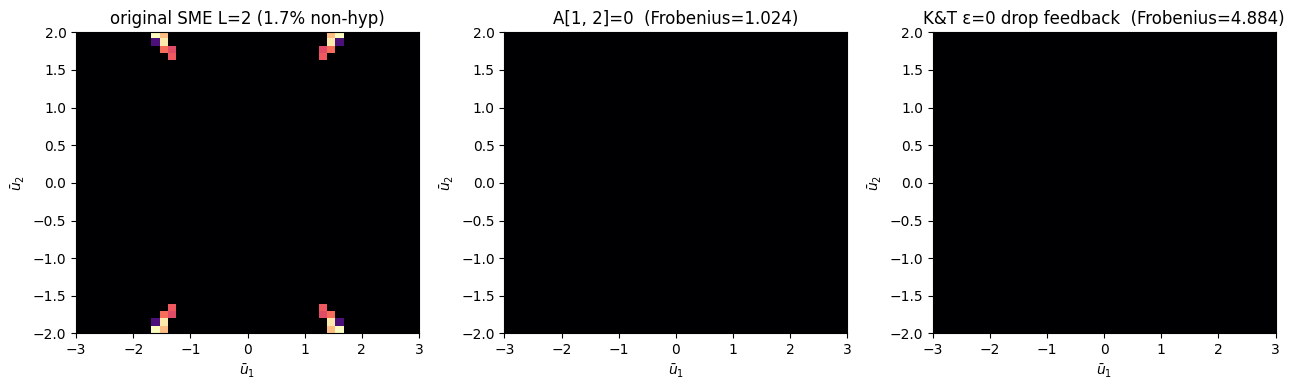

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
extent = [u1g.min(), u1g.max(), u2g.min(), u2g.max()]

# Original
nh_grid = np.zeros((n_pts, n_pts))
for i in range(n_pts):
    for j in range(n_pts):
        nh_grid[j, i] = np.max(np.abs(np.imag(np.linalg.eigvals(A_grid[i, j]))))
axes[0].imshow(nh_grid, extent=extent, origin="lower", aspect="auto", cmap="magma")
axes[0].set_title(f"original SME L=2 ({nh_orig:.1%} non-hyp)")
axes[0].set_xlabel(r"$\bar u_1$"); axes[0].set_ylabel(r"$\bar u_2$")

# Single-entry minimum
nh_grid = np.zeros((n_pts, n_pts))
r, c = best[0]
for i in range(n_pts):
    for j in range(n_pts):
        A_mod = A_grid[i, j].copy(); A_mod[r, c] = 0
        nh_grid[j, i] = np.max(np.abs(np.imag(np.linalg.eigvals(A_mod))))
axes[1].imshow(nh_grid, extent=extent, origin="lower", aspect="auto", cmap="magma")
axes[1].set_title(f"A[{r}, {c}]=0  (Frobenius={best[2]:.3f})")
axes[1].set_xlabel(r"$\bar u_1$"); axes[1].set_ylabel(r"$\bar u_2$")

# Drop feedback (K&T-equivalent)
f_M_x_uu = sp.lambdify(syms_b, M_x_uu, "numpy")
nh_grid = np.zeros((n_pts, n_pts))
fro_avg = 0.0
for i, U1 in enumerate(u1g):
    for j, U2 in enumerate(u2g):
        Mt = np.asarray(f_M_t(gv, H, U0, float(U1), float(U2)), float)
        Mxu = np.asarray(f_M_x_uu(gv, H, U0, float(U1), float(U2)), float)
        A_drop = np.linalg.solve(Mt, Mxu)
        fro_avg += np.linalg.norm(A_drop - A_grid[i, j], "fro")
        nh_grid[j, i] = np.max(np.abs(np.imag(np.linalg.eigvals(A_drop))))
fro_avg /= n_pts**2
axes[2].imshow(nh_grid, extent=extent, origin="lower", aspect="auto", cmap="magma")
axes[2].set_title(f"K&T ε=0 drop feedback  (Frobenius={fro_avg:.3f})")
axes[2].set_xlabel(r"$\bar u_1$"); axes[2].set_ylabel(r"$\bar u_2$")

plt.tight_layout()
plt.savefig("../tutorials/sme/sme_l2_min_entry_compare.png", dpi=140, bbox_inches="tight")
plt.show()

## 6. Newtonian τ_xx as parabolic regularisation

Adding `τ_xx = 2ν · ∂_x u` to the x-momentum equation gives a viscous
decay term that competes with the inviscid loss-of-hyperbolicity. The
coefficient matrix at homogeneous base is super-diagonal:
`M_visc[i, i+1] = h̄/(2i+1)` for `i ∈ {0, 1, 2}` and zero on the KBC row.

At fixed wavenumber `k = 1`, increasing `ν` shifts `Im ω(k)` from
positive (unstable) to negative (decay). With `ν ≥ 0.1` the entire
`(ū_1, ū_2)` grid is dispersively stable — but **the principal symbol
is unchanged**, since `τ_xx` is a lower-order term. So:

- Strict hyperbolicity (real eigenvalues of `M_t⁻¹·M_x`): **No**.
- Dispersive well-posedness (`Im ω(k) ≤ 0` at fixed `k`): **Yes** with
  sufficient ν.

For schemes that depend on strict hyperbolicity (Riemann solvers,
explicit FV) viscous SME is *not* a substitute for an algebraic fix.
For implicit / IMEX time integration it is well-posed.

## 7. Does the pattern scale to higher L?

**L=3 single-entry search** (`tutorials/sme/sme_l3_single_entry_search.py`,
15×15 grid over `(ū_2, ū_3) ∈ [−2.5, 2.5]²`, ū_0 = ū_1 = 0):

| entry | non-hyp % | ⟨‖·‖_F⟩ | comment |
|---|---|---|---|
| original SME L=3 | 19.56 % | — | baseline |
| **`A[2, 4] = 0`** | **0.00 %** | **0.571** | u_3 → u_1-equation coupling |
| `A[3, 2] = 0` | 0.00 % | 1.714 | u_1 → u_2-equation coupling |
| `A[4, 3] = 0` | 5.33 % | 0.533 | partial fix |

At L = 3 a single entry still suffices, with **even smaller Frobenius
norm than at L = 2** (0.57 vs 1.02). The targeted entry is *different*
at each L — at L=2 it was the second-mode → mean coupling, at L=3 it's
the top-mode → second-mode coupling — but the existence of an O(1)
single-entry fix appears robust.

**The empirical pattern.** At L = 2 and L = 3 the unstable eigenvector
is dominated by the top two moments. At every level, the simplest
single-entry fix targets a coupling between high modes.

**Eigenvalues vs proof.** Sampling eigenvalues over a `(ū_1, ū_2, …)` grid
*demonstrates* hyperbolicity at the sampled states — it does not prove
hyperbolicity globally. To prove globally, one constructs the
characteristic polynomial `det(λI − A)` symbolically and shows its
discriminant is non-negative for all admissible base states. For L = 2
this is feasible by hand or `sympy.discriminant(charpoly, λ)`; for
L ≥ 4 the symbolic discriminant is too large to be informative.

A practical proof strategy at higher L:
1. Show the regularised matrix has a *symmetrisable* form
   (∃ S = Sᵀ ≻ 0 such that S·A is symmetric).
2. The symmetrisable property is local in the base-state, but is often
   proven by exhibiting an explicit S (the energy quadratic form).

Whether our single-entry regularisation is symmetrisable under the
energy norm `W = diag(g, h, h/3, h/5, …)` is a concrete next item that
would generalise the result to all L.